# Müşteri Kaybı (Churn) Tahmini Projesi
Bu notebook, telekom müşteri verileri kullanılarak müşteri kaybını (churn) tahmin etmeye yönelik bir makine öğrenmesi çalışmasını içermektedir. Veri ön işleme, keşifsel veri analizi ve farklı sınıflandırma algoritmalarıyla (Lojistik Regresyon, SVM) model eğitimi adımlarını kapsar.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [24]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df.drop("customerID", axis=1, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
for i in df.columns:
    print(i)
    print(df[i].unique())

gender
['Female' 'Male']
SeniorCitizen
[0 1]
Partner
['Yes' 'No']
Dependents
['No' 'Yes']
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService
['No' 'Yes']
MultipleLines
['No phone service' 'No' 'Yes']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['Yes' 'No' 'No internet service']
DeviceProtection
['No' 'Yes' 'No internet service']
TechSupport
['No' 'Yes' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['Month-to-month' 'One year' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges
[29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges
['29.85' '1889

In [28]:
df["gender"]=df["gender"].replace({
    "Female" : 1,
    "Male" : 0,
})
df.head()

C:\Users\tolga\AppData\Local\Temp\ipykernel_15588\4267767310.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gender"]=df["gender"].replace({


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,0,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,1,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
binary_col=df[["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]]

for i in binary_col:
    df[i]= df[i].map({
        "Yes" : 1,
        "No" :0    
    })

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,0,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [30]:
categorical_cols = [
    'InternetService',
    'Contract',             
    'PaymentMethod',        
    'MultipleLines',        
    'OnlineSecurity',   #Tek tek yazmamak için AI kullanıldı  
    'OnlineBackup',         
    'DeviceProtection',     
    'TechSupport',          
    'StreamingTV',          
    'StreamingMovies'       
]

df= pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,1,0,1,0,1,0,1,29.85,29.85,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,34,1,0,56.95,1889.5,0,...,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,2,1,1,53.85,108.15,1,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,0,0,0,1,0,1,0,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,0,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   object 
 9   Churn                                  7043 non-null   int64  
 10  InternetService_Fiber optic            7043 non-null   int64  
 11  Inte

In [39]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  InternetService_Fiber optic            7043 non-null   int64  
 11  Inte

In [43]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [45]:
df[df["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
488,1,0,1,1,0,0,1,52.55,NaN,0,...,0,0,0,1,0,1,0,1,0,0
753,0,0,0,1,0,1,0,20.25,NaN,0,...,1,0,1,0,1,0,1,0,1,0
936,1,0,1,1,0,1,0,80.85,NaN,0,...,0,1,0,1,0,0,0,1,0,1
1082,0,0,1,1,0,1,0,25.75,NaN,0,...,1,0,1,0,1,0,1,0,1,0
1340,1,0,1,1,0,0,0,56.05,NaN,0,...,0,1,0,1,0,1,0,1,0,0
3331,0,0,1,1,0,1,0,19.85,NaN,0,...,1,0,1,0,1,0,1,0,1,0
3826,0,0,1,1,0,1,0,25.35,NaN,0,...,1,0,1,0,1,0,1,0,1,0
4380,1,0,1,1,0,1,0,20.00,NaN,0,...,1,0,1,0,1,0,1,0,1,0
5218,0,0,1,1,0,1,1,19.70,NaN,0,...,1,0,1,0,1,0,1,0,1,0
6670,1,0,1,1,0,1,0,73.35,NaN,0,...,0,1,0,1,0,1,0,1,0,0


In [47]:
df.shape

(7043, 31)

In [48]:
df.drop(df[df["TotalCharges"].isnull()].index, inplace=True)
df["TotalCharges"].isnull().sum()

np.int64(0)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  InternetService_Fiber optic            7032 non-null   int64  
 11  InternetS

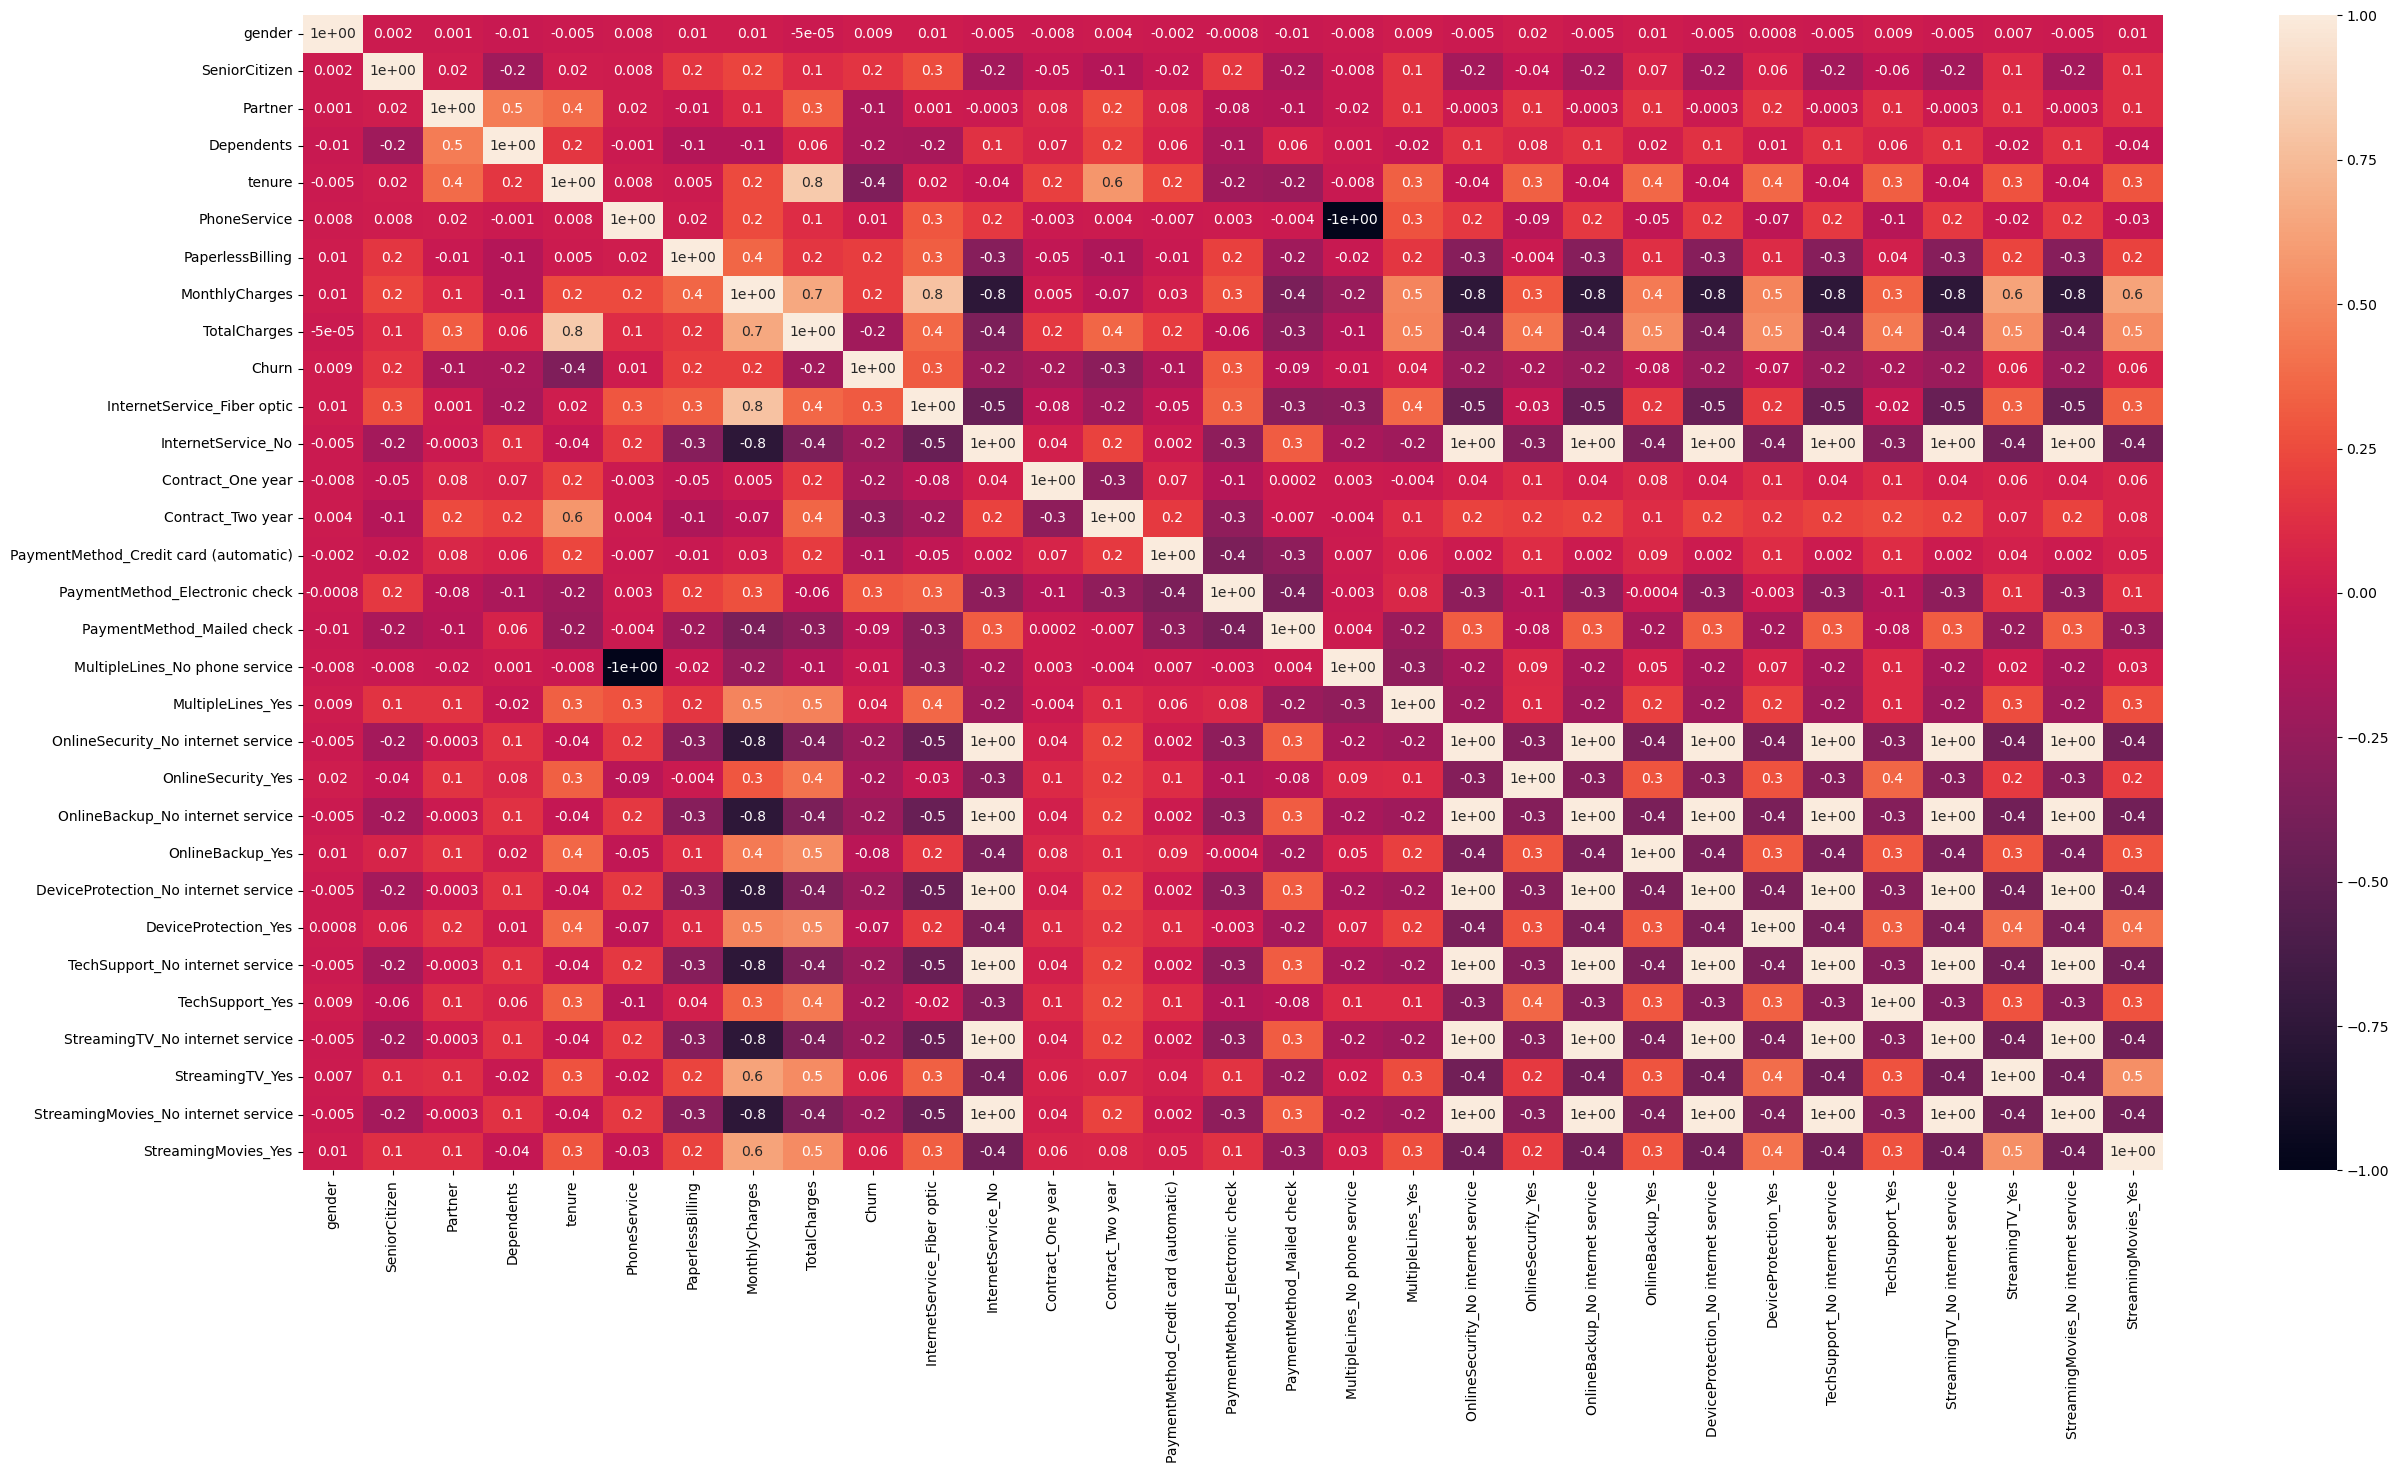

In [52]:
plt.figure(figsize=(30,15))
sns.heatmap(df.corr(), annot=True, fmt=".1")
plt.show()

In [54]:
X= df.drop("Churn", axis=1)
y= df["Churn"]

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=15, test_size=0.25)

In [59]:
from sklearn.preprocessing import StandardScaler
numeric_cat=["tenure", "MonthlyCharges", "TotalCharges"]

scaler=StandardScaler()

X_train[numeric_cat]= scaler.fit_transform(X_train[numeric_cat])
X_test[numeric_cat]= scaler.transform(X_test[numeric_cat])

X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
2846,1,0,1,0,-1.243021,1,1,-0.082421,-0.958999,0,...,0,0,0,0,0,0,0,0,0,1
3960,1,0,0,0,-1.201970,1,0,-0.235559,-0.937372,0,...,0,0,0,1,0,0,0,1,0,0
4588,1,0,1,0,0.029554,1,1,1.011190,0.335997,1,...,0,0,0,1,0,1,0,0,0,1
5457,1,0,1,1,-0.873564,1,0,-0.453616,-0.749388,0,...,0,0,0,0,0,0,0,0,0,0
3709,0,0,0,0,-1.284072,1,0,-0.461938,-0.986889,0,...,0,0,0,0,0,0,0,0,0,0


In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [68]:
params={
    "penalty" : ["l1", "l2", "elasticnet"],
    "C" : [0.01, 0.1, 1, 10, 100, 1000 ],
    "solver" :["newton-cg", "lbfgs", "liblinear", "sag", "saga", "newton-cholesky"],
    "class_weight" : ["balanced", None]
}

In [69]:
logistic=GridSearchCV(estimator=model, param_grid=params, cv=5, scoring="accuracy", n_jobs=-1)
logistic.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
600 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver 

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000],
                         'class_weight': ['balanced', None],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga', 'newton-cholesky']},
             scoring='accuracy')

In [70]:
logistic.best_params_

{'C': 10, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}

In [72]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred= logistic.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.8111490329920364
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1292
           1       0.68      0.54      0.60       466

    accuracy                           0.81      1758
   macro avg       0.76      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758

[[1173  119]
 [ 213  253]]


In [73]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [77]:
params={'C': [10],
        'class_weight': ["balanced"],
        'penalty': ['l1'] ,
        'solver': ['liblinear']}
logistic=GridSearchCV(estimator=model, param_grid=params, cv=5, n_jobs=-1, scoring="f1")
logistic.fit(X_train, y_train)
y_pred=logistic.predict(X_test)

In [78]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.7411831626848692
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1292
           1       0.51      0.78      0.61       466

    accuracy                           0.74      1758
   macro avg       0.70      0.75      0.71      1758
weighted avg       0.80      0.74      0.75      1758

[[941 351]
 [104 362]]


In [79]:
from sklearn.svm import SVC
svc=SVC()

In [81]:
params_svc={
    "C": [0.01, 0.1, 1, 10, 100],
    "kernel": ["rbf", "linear"],
    "gamma" : ["auto", "scale"],
    "class_weight":["balanced"]
}

grid_svc=GridSearchCV(estimator=svc, param_grid=params_svc, cv=5, n_jobs=-1, scoring="f1")

grid_svc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': ['balanced'],
                         'gamma': ['auto', 'scale'],
                         'kernel': ['rbf', 'linear']},
             scoring='f1')

In [82]:
y_pred=grid_svc.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.7320819112627986
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1292
           1       0.50      0.77      0.61       466

    accuracy                           0.73      1758
   macro avg       0.70      0.75      0.70      1758
weighted avg       0.79      0.73      0.75      1758

[[926 366]
 [105 361]]


In [83]:
grid_svc.best_params_

{'C': 0.01, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'linear'}

In [88]:
scv_params={
    'C': [0.01],
    'class_weight': [{0 : x, 1 : y} for x in [0.01, 0.1, 1, 10] for y in [0.01, 0.1, 1, 10]], 
    'gamma': ['auto'],
    'kernel': ['linear']
}

grid_svc=GridSearchCV(estimator=svc, param_grid=scv_params, n_jobs=-1, cv=5, scoring="f1")
grid_svc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01],
                         'class_weight': [{0: 0.01, 1: 0.01}, {0: 0.01, 1: 0.1},
                                          {0: 0.01, 1: 1}, {0: 0.01, 1: 10},
                                          {0: 0.1, 1: 0.01}, {0: 0.1, 1: 0.1},
                                          {0: 0.1, 1: 1}, {0: 0.1, 1: 10},
                                          {0: 1, 1: 0.01}, {0: 1, 1: 0.1},
                                          {0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 10, 1: 0.01}, {0: 10, 1: 0.1},
                                          {0: 10, 1: 1}, {0: 10, 1: 10}],
                         'gamma': ['auto'], 'kernel': ['linear']},
             scoring='f1')

In [91]:
y_pred=grid_svc.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.79806598407281
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1292
           1       0.65      0.51      0.57       466

    accuracy                           0.80      1758
   macro avg       0.74      0.70      0.72      1758
weighted avg       0.79      0.80      0.79      1758

[[1167  125]
 [ 230  236]]


In [92]:
grid_svc.best_params_

{'C': 0.01,
 'class_weight': {0: 10, 1: 10},
 'gamma': 'auto',
 'kernel': 'linear'}

In [93]:
scv_params={
    'C': [0.01],
    'class_weight': [{0 : x, 1 : y} for x in [5,10, 100] for y in [ 5, 10, 100]], 
    'gamma': ['auto'],
    'kernel': ['linear']
}
grid_svc=GridSearchCV(estimator=svc, param_grid=scv_params, n_jobs=-1, cv=5, scoring="f1")
grid_svc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01],
                         'class_weight': [{0: 5, 1: 5}, {0: 5, 1: 10},
                                          {0: 5, 1: 100}, {0: 10, 1: 5},
                                          {0: 10, 1: 10}, {0: 10, 1: 100},
                                          {0: 100, 1: 5}, {0: 100, 1: 10},
                                          {0: 100, 1: 100}],
                         'gamma': ['auto'], 'kernel': ['linear']},
             scoring='f1')

In [95]:
y_pred=grid_svc.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.7605233219567691
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1292
           1       0.54      0.73      0.62       466

    accuracy                           0.76      1758
   macro avg       0.71      0.75      0.72      1758
weighted avg       0.80      0.76      0.77      1758

[[995 297]
 [124 342]]


In [96]:
grid_svc.best_params_

{'C': 0.01, 'class_weight': {0: 5, 1: 10}, 'gamma': 'auto', 'kernel': 'linear'}